In [1]:
%%capture
pip install plotly>=6.1.1 kaleido==0.2.1

In [40]:
import pandas as pd
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data = pd.read_csv("/content/drive/MyDrive/ADS_CW_Data/merged_all_locations_yearly_1990_2018_clean.csv")
display(data)

,year,temp_mean_K,wind_speed_mean_ms,precip_total_mm,location_code,city,country,population,built_up_area_m2,gdp_ppp,hdi,pop_exposed_flood_10yr,co2_emissions_ton,ghg_emissions_ton,nox_emissions_ton,pm25_emissions_ton
0,1990,289.539768,8.263012,594.433150,-33.9N_18.5E,Cape Town,South Africa,2.028241e+06,136652367.0,4.067584e+07,0.7110,206.090,7.212327e+06,9.070311e+06,25096.370368,12116.047542
1,1991,289.317261,7.360679,460.223021,-33.9N_18.5E,Cape Town,South Africa,2.073430e+06,138453452.2,4.104569e+07,0.7178,209.610,7.260609e+06,9.165988e+06,25366.976159,12160.387767
2,1992,289.372513,8.470232,650.794682,-33.9N_18.5E,Cape Town,South Africa,2.118618e+06,140254537.4,4.141554e+07,0.7246,213.130,7.308891e+06,9.261665e+06,25637.581949,12204.727991
3,1993,289.674092,7.512518,572.032984,-33.9N_18.5E,Cape Town,South Africa,2.163806e+06,142055622.6,4.178539e+07,0.7314,216.650,7.357174e+06,9.357342e+06,25908.187740,12249.068216
4,1994,289.775767,7.520717,432.921544,-33.9N_18.5E,Cape Town,South Africa,2.208994e+06,143856707.8,4.215524e+07,0.7382,220.170,7.405456e+06,9.453019e+06,26178.793531,12293.408441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,2013,280.444239,3.818887,863.767772,59.92N_10.75E,Oslo,Norway,7.739188e+05,33006484.6,1.403080e+08,0.9616,7112.244,1.917091e+06,2.660930e+06,4006.022489,2568.231376
268,2014,282.047160,3.847784,1174.514431,59.92N_10.75E,Oslo,Norway,7.855763e+05,33276955.8,1.427155e+08,0.9618,7225.452,1.910392e+06,2.500929e+06,4017.810216,2393.495818
269,2016,281.035418,3.868147,766.193022,59.92N_10.75E,Oslo,Norway,7.972339e+05,33547427.0,1.451230e+08,0.9620,7338.660,1.903694e+06,2.340928e+06,4029.597944,2218.760260
270,2017,281.146538,3.906407,867.359529,59.92N_10.75E,Oslo,Norway,7.972339e+05,33547427.0,1.451230e+08,0.9620,7338.660,1.903694e+06,2.340928e+06,4029.597944,2218.760260


In [20]:
def plot_correlation_heatmap(df, cols1, cols2=None, title='Correlation Matrix', figsize=(12, 10), save_as_filename=None):
    """
    Generates and displays a correlation heatmap for specified columns.

    Args:
        df (pd.DataFrame): The input DataFrame.
        cols1 (list): List of columns for the rows of the correlation matrix.
        cols2 (list, optional): List of columns for the columns of the correlation matrix
                                 (for cross-correlation). If None, calculates full correlation
                                 for cols1. Defaults to None.
        title (str, optional): Title of the heatmap. Defaults to 'Correlation Matrix'.
        figsize (tuple, optional): Figure size for the heatmap. Defaults to (12, 10).
        save_as_filename (str, optional): If provided, saves the plot as a PDF with this name.
                                          The file will be saved to '/content/drive/MyDrive/ADS_CW_Data/{file_name}.pdf'.
                                          Defaults to None (plot is not saved).
    """
    if cols2:
        # Cross-correlation
        combined_cols = list(set(cols1 + cols2)) # Use set to avoid duplicates if any
        correlation_matrix = df[combined_cols].corr().loc[cols1, cols2]
    else:
        # Full correlation
        correlation_matrix = df[cols1].corr()

    if correlation_matrix.empty:
        print(f"No correlation data to display for the given columns: {cols1} and {cols2 if cols2 else 'None'}")
        return

    plt.figure(figsize=figsize)
    mask = np.zeros_like(correlation_matrix, dtype=bool) if not cols2 else None # Mask only for full correlation
    sns.heatmap(correlation_matrix, mask=mask,
                cmap=sns.diverging_palette(220, 10, as_cmap=True), square=True, annot=True,
                fmt=".2f", linewidths=.5, cbar_kws={"shrink": .5 if not cols2 else .7}, vmin=-1.0, vmax=1.0)
    plt.title(title, fontsize=16 if not cols2 else 14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_as_filename:
        save_path = os.path.join('/content/drive/MyDrive/ADS_CW_Data', f'{save_as_filename}.pdf')
        plt.savefig(save_path)
        print(f"Figure saved to {save_path}")

    plt.show()

--- Full Correlation Matrix ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/full_correlation_matrix.pdf


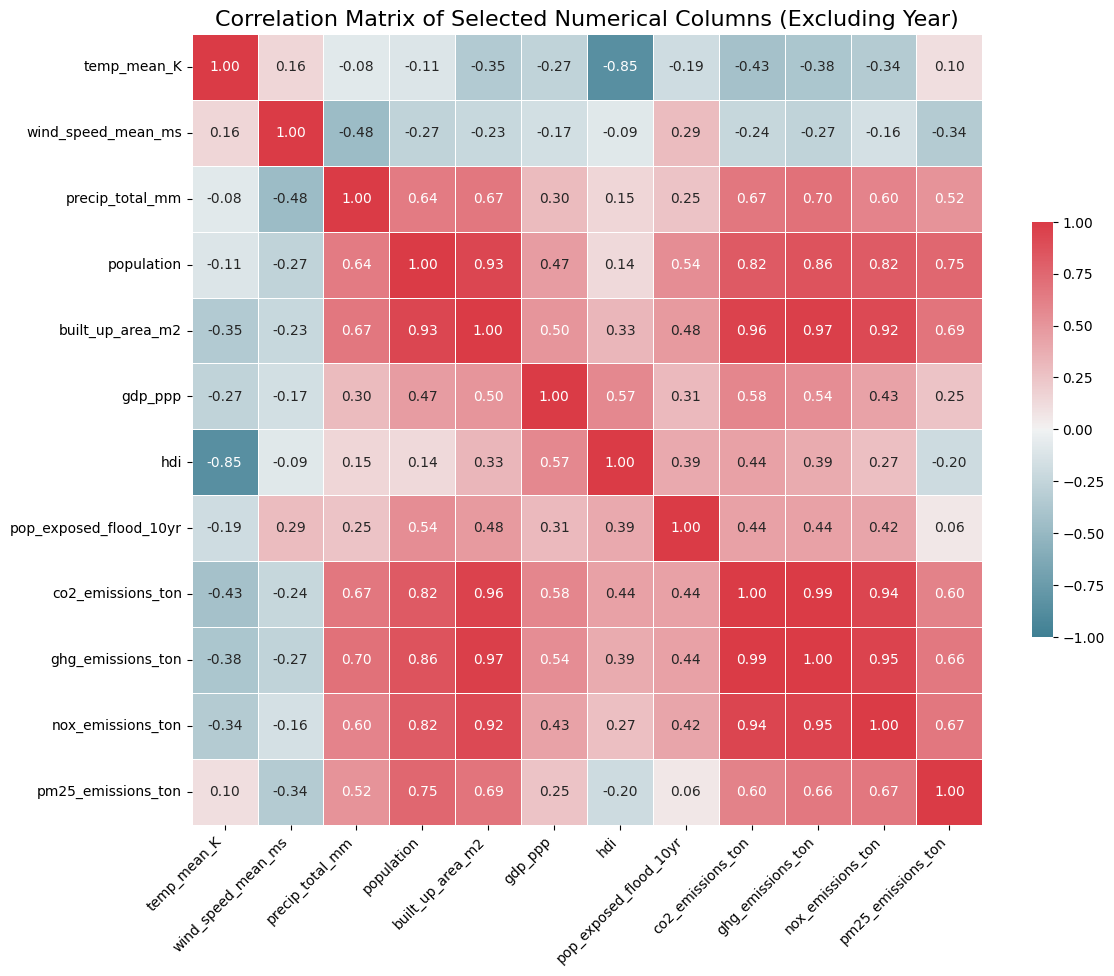


--- Cross-Correlation Matrix ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/cross_correlation_matrix_weather_others.pdf


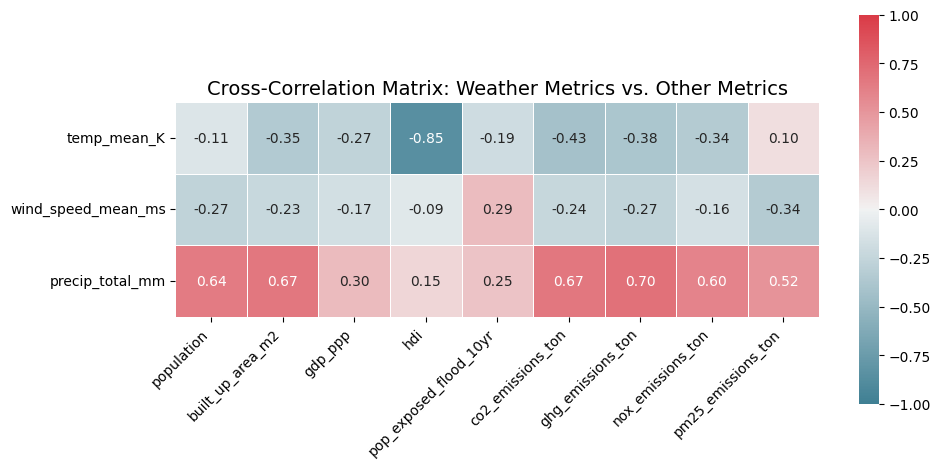

In [21]:
numerical_cols = [
    'temp_mean_K', 'wind_speed_mean_ms', 'precip_total_mm', 'population',
    'built_up_area_m2', 'gdp_ppp', 'hdi', 'pop_exposed_flood_10yr',
    'co2_emissions_ton', 'ghg_emissions_ton', 'nox_emissions_ton', 'pm25_emissions_ton'
]

print("--- Full Correlation Matrix ---")
plot_correlation_heatmap(data, numerical_cols,
                         title='Correlation Matrix of Selected Numerical Columns (Excluding Year)',
                         figsize=(12, 10),
                         save_as_filename='full_correlation_matrix')

weather_metrics = ['temp_mean_K', 'wind_speed_mean_ms', 'precip_total_mm']
remainder_metrics = [col for col in numerical_cols if col not in weather_metrics]

print("\n--- Cross-Correlation Matrix ---")
if not weather_metrics or not remainder_metrics:
    print("Error: Both weather metrics and other metrics lists must not be empty.")
else:
    plot_correlation_heatmap(data, weather_metrics, remainder_metrics,
                             title='Cross-Correlation Matrix: Weather Metrics vs. Other Metrics',
                             figsize=(10, 6),
                             save_as_filename='cross_correlation_matrix_weather_others')

In [27]:
def plot_scatter_with_regression_plotly(df, feature1, feature2, save_as_filename=None):
    """
    Generates an interactive scatter plot with a regression line for two specified features
    from a DataFrame using Plotly.

    Args:
        df (pd.DataFrame): The input DataFrame.
        feature1 (str): The name of the first feature (for the x-axis).
        feature2 (str): The name of the second feature (for the y-axis).
        save_as_filename (str, optional): If provided, saves the plot as a PDF with this name.
                                          The file will be saved to '/content/drive/MyDrive/ADS_CW_Data/{file_name}.pdf'.
                                          Defaults to None (plot is not saved).
    """
    from scipy.stats import linregress

    if feature1 not in df.columns or feature2 not in df.columns:
        print(f"Error: One or both of the specified features ('{feature1}', '{feature2}') not found in the DataFrame.")
        return

    if not pd.api.types.is_numeric_dtype(df[feature1]) or not pd.api.types.is_numeric_dtype(df[feature2]):
        print(f"Error: Both features ('{feature1}', '{feature2}') must be numerical.")
        return

    # Drop NaNs for regression calculation to avoid errors
    temp_df = df[[feature1, feature2]].dropna()

    if temp_df.empty:
        print(f"No valid data points for regression between '{feature1}' and '{feature2}' after dropping NaNs.")
        return

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(temp_df[feature1], temp_df[feature2])

    # Print regression results
    print(f"\n--- Regression Analysis Results for {feature1} vs. {feature2}---")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Standard Error: {std_err:.4f}")
    print("--------------------------------------------------")

    fig = px.scatter(df, x=feature1, y=feature2, trendline='ols',
                     title=f'Scatter Plot of {feature1.replace("_", " ").title()} vs. {feature2.replace("_", " ").title()} with Regression Line')

    fig.update_layout(
        xaxis_title=feature1.replace('_', ' ').title(),
        yaxis_title=feature2.replace('_', ' ').title()
    )

    if save_as_filename:
        save_path = os.path.join('/content/drive/MyDrive/ADS_CW_Data', f'{save_as_filename}.pdf')
        try:
            fig.write_image(save_path)
            print(f"Figure saved to {save_path}")
        except Exception as e:
            print(f"Could not save figure to PDF: {e}. Make sure 'kaleido' is installed.")

    fig.show()

In [28]:
plot_scatter_with_regression_plotly(data, 'temp_mean_K', 'hdi', 'scatter_temp_hdi')
plot_scatter_with_regression_plotly(data, 'precip_total_mm', 'ghg_emissions_ton', 'scatter_precip_ghg')
plot_scatter_with_regression_plotly(data, 'precip_total_mm', 'co2_emissions_ton', 'scatter_precip_co2')
plot_scatter_with_regression_plotly(data, 'precip_total_mm', 'nox_emissions_ton', 'scatter_precip_nox')
plot_scatter_with_regression_plotly(data, 'precip_total_mm', 'pm25_emissions_ton', 'scatter_precip_pm25')



--- Regression Analysis Results for temp_mean_K vs. hdi---
Slope: -0.0117
Intercept: 4.2037
R-squared: 0.7268
P-value: 0.0000
Standard Error: 0.0004
--------------------------------------------------
Figure saved to /content/drive/MyDrive/ADS_CW_Data/scatter_temp_hdi.pdf



--- Regression Analysis Results for precip_total_mm vs. ghg_emissions_ton---
Slope: 49947.5672
Intercept: -21783721.3051
R-squared: 0.4847
P-value: 0.0000
Standard Error: 3134.4420
--------------------------------------------------
Figure saved to /content/drive/MyDrive/ADS_CW_Data/scatter_precip_ghg.pdf



--- Regression Analysis Results for precip_total_mm vs. co2_emissions_ton---
Slope: 44548.3138
Intercept: -20193280.4456
R-squared: 0.4423
P-value: 0.0000
Standard Error: 3044.2379
--------------------------------------------------
Figure saved to /content/drive/MyDrive/ADS_CW_Data/scatter_precip_co2.pdf



--- Regression Analysis Results for precip_total_mm vs. nox_emissions_ton---
Slope: 99.7311
Intercept: -38875.3398
R-squared: 0.3590
P-value: 0.0000
Standard Error: 8.1095
--------------------------------------------------
Figure saved to /content/drive/MyDrive/ADS_CW_Data/scatter_precip_nox.pdf



--- Regression Analysis Results for precip_total_mm vs. pm25_emissions_ton---
Slope: 14.1881
Intercept: -1498.1687
R-squared: 0.2657
P-value: 0.0000
Standard Error: 1.4353
--------------------------------------------------
Figure saved to /content/drive/MyDrive/ADS_CW_Data/scatter_precip_pm25.pdf


In [50]:
def plot_feature_over_time_plotly(df, main_feature_col, additional_feature_cols=None, locations=None, save_as_filename=None):
    """
    Generates an interactive line plot of a chosen main feature over time,
    with optional additional features, for specified locations using Plotly.
    Additional features are plotted on a secondary y-axis if provided.

    Args:
        df (pd.DataFrame): The input DataFrame.
        main_feature_col (str): The name of the primary feature column to plot.
        additional_feature_cols (list, optional): A list of additional feature columns to plot
                                                  on the secondary y-axis. Defaults to None.
        locations (list, optional): A list of location_codes to include in the plot.
                                    If None, all locations present in the dataframe will be plotted.
                                    Defaults to None.
        save_as_filename (str, optional): If provided, saves the plot as a PDF with this name.
                                          The file will be saved to '/content/drive/MyDrive/ADS_CW_Data/{file_name}.pdf'.
                                          Defaults to None (plot is not saved).
    """

    # Input validation for main_feature_col
    if main_feature_col not in df.columns:
        print(f"Error: Main feature column '{main_feature_col}' not found in the DataFrame.")
        return
    if not pd.api.types.is_numeric_dtype(df[main_feature_col]):
        print(f"Error: Main feature column '{main_feature_col}' must be numerical.")
        return

    # Input validation for additional_feature_cols
    if additional_feature_cols:
        for feature_col in additional_feature_cols:
            if feature_col not in df.columns:
                print(f"Error: Additional feature column '{feature_col}' not found in the DataFrame.")
                return
            if not pd.api.types.is_numeric_dtype(df[feature_col]):
                print(f"Error: Additional feature column '{feature_col}' must be numerical.")
                return

    if 'year' not in df.columns:
        print("Error: 'year' column not found in the DataFrame. Cannot plot over time.")
        return
    if 'location_code' not in df.columns:
        print("Error: 'location_code' column not found in the DataFrame. Required for multi-location plotting.")
        return

    # Prepare the DataFrame for plotting
    if locations:
        plot_df = df[df['location_code'].isin(locations)].copy()
        if plot_df.empty:
            print(f"No data found for the specified locations: {locations}")
            return
    else:
        plot_df = df.copy()

    # Create a descriptive location name if 'city' and 'country' columns exist
    if 'city' in plot_df.columns and 'country' in plot_df.columns:
        plot_df['location_display_name'] = plot_df['city'] + ', ' + plot_df['country']
        color_col = 'location_display_name'
        legend_title = 'Location'
    else:
        color_col = 'location_code'
        legend_title = 'Location Code'
        print("Warning: 'city' or 'country' columns not found. Using 'location_code' for labels.")

    # Sort by year for proper line plotting
    plot_df = plot_df.sort_values(by=['year', color_col])

    # Create figure with secondary y-axis if additional features are present
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    unique_locations = plot_df[color_col].unique()

    # Define colors and dash patterns for additional features
    color_map = {'temp_mean_K': '#ff7f0e', 'precip_total_mm': '#2ca02c'}
    dash_map = {'temp_mean_K': 'dot', 'precip_total_mm': 'dot'}

    for i, location in enumerate(unique_locations):
        location_df = plot_df[plot_df[color_col] == location]

        # Add main feature trace
        fig.add_trace(go.Scatter(x=location_df['year'], y=location_df[main_feature_col],
                                 mode='lines+markers',
                                 name=f'{location} - {main_feature_col.replace("_", " ").title()}',
                                 legendgroup=f'{location}',
                                 showlegend=True
                                 ),
                      secondary_y=False) # Primary Y-axis

        # Add additional feature traces on secondary Y-axis
        if additional_feature_cols:
            for add_feature in additional_feature_cols:
                line_style = dict(dash=dash_map.get(add_feature, 'dot'), color=color_map.get(add_feature, 'grey'))
                fig.add_trace(go.Scatter(x=location_df['year'], y=location_df[add_feature],
                                         mode='lines',
                                         name=f'{location} - {add_feature.replace("_", " ").title()}',
                                         legendgroup=f'{location}',
                                         line=line_style,
                                         showlegend=True),
                              secondary_y=True) # Secondary Y-axis

    # Update layout and titles
    title_text = f'{main_feature_col.replace("_", " ").title()} Over Time by Location'
    if additional_feature_cols:
        title_text += f' with {", ".join([f.replace("_", " ").title() for f in additional_feature_cols])}'

    fig.update_layout(
        title_text=title_text,
        xaxis_title='Year',
        yaxis_title=main_feature_col.replace('_', ' ').title(),
        legend_title=legend_title
    )

    # Set secondary y-axis label
    if additional_feature_cols:
        secondary_y_label = ', '.join([f.replace("_", " ").title() for f in additional_feature_cols])
        fig.update_yaxes(title_text=secondary_y_label, secondary_y=True)

    if save_as_filename:
        save_path = os.path.join('/content/drive/MyDrive/ADS_CW_Data', f'{save_as_filename}.pdf')
        try:
            fig.write_image(save_path)
            print(f"Figure saved to {save_path}")
        except Exception as e:
            print(f"Could not save figure to PDF: {e}. Make sure 'kaleido' is installed.'")

    fig.show()

In [51]:
# Define the numerical columns to plot (excluding 'year', 'latitude', 'longitude' if they exist, as they are not features to be plotted in this manner)
selected_numerical_cols = numerical_cols # numerical_cols already defined and suitable
hyderabad_location_code = '17.36N_78.5E'
weather_features = ['temp_mean_K', 'precip_total_mm']

print(f"Generating line plots for numerical features over time for Hyderabad ({hyderabad_location_code}):")

for feature in selected_numerical_cols:
    # Skip plotting weather features as main features, they will be added as additional features
    if feature in weather_features:
        continue

    print(f"\n--- Plotting: {feature.replace('_', ' ').title()} with Temperature ---")
    plot_feature_over_time_plotly(
        data,
        main_feature_col=feature,
        additional_feature_cols=['temp_mean_K'],
        locations=[hyderabad_location_code],
        save_as_filename=f'line_{feature}_with_temp_hyderabad'
    )

    print(f"\n--- Plotting: {feature.replace('_', ' ').title()} with Precipitation ---")
    plot_feature_over_time_plotly(
        data,
        main_feature_col=feature,
        additional_feature_cols=['precip_total_mm'],
        locations=[hyderabad_location_code],
        save_as_filename=f'line_{feature}_with_precip_hyderabad'
    )

Generating line plots for numerical features over time for Hyderabad (17.36N_78.5E):

--- Plotting: Wind Speed Mean Ms with Temperature ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_wind_speed_mean_ms_with_temp_hyderabad.pdf



--- Plotting: Wind Speed Mean Ms with Precipitation ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_wind_speed_mean_ms_with_precip_hyderabad.pdf



--- Plotting: Population with Temperature ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_population_with_temp_hyderabad.pdf



--- Plotting: Population with Precipitation ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_population_with_precip_hyderabad.pdf



--- Plotting: Built Up Area M2 with Temperature ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_built_up_area_m2_with_temp_hyderabad.pdf


...


--- Plotting: Ghg Emissions Ton with Precipitation ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_ghg_emissions_ton_with_precip_hyderabad.pdf



--- Plotting: Nox Emissions Ton with Temperature ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_nox_emissions_ton_with_temp_hyderabad.pdf



--- Plotting: Nox Emissions Ton with Precipitation ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_nox_emissions_ton_with_precip_hyderabad.pdf



--- Plotting: Pm25 Emissions Ton with Temperature ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_pm25_emissions_ton_with_temp_hyderabad.pdf



--- Plotting: Pm25 Emissions Ton with Precipitation ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/line_pm25_emissions_ton_with_precip_hyderabad.pdf


In [15]:
def plot_decile_analysis_plotly(df, decile_feature, avg_feature, save_as_filename=None):
    """
    Generates an interactive bar plot showing the average of a feature
    for each decile of another feature using Plotly.

    Args:
        df (pd.DataFrame): The input DataFrame.
        decile_feature (str): The name of the numerical feature to create deciles from.
        avg_feature (str): The name of the numerical feature to average within each decile.
        save_as_filename (str, optional): If provided, saves the plot as a PDF with this name.
                                          The file will be saved to '/content/drive/MyDrive/ADS_CW_Data/{file_name}.pdf'.
                                          Defaults to None (plot is not saved).
    """
    if decile_feature not in df.columns or avg_feature not in df.columns:
        print(f"Error: One or both of the specified features ('{decile_feature}', '{avg_feature}') not found in the DataFrame.")
        return

    if not pd.api.types.is_numeric_dtype(df[decile_feature]) or not pd.api.types.is_numeric_dtype(df[avg_feature]):
        print(f"Error: Both features ('{decile_feature}', '{avg_feature}') must be numerical.")
        return

    # Drop rows with NaN in relevant columns for decile calculation
    temp_df = df[[decile_feature, avg_feature]].dropna().copy()

    if temp_df.empty:
        print("No valid data for decile analysis after dropping NaNs.")
        return

    # Calculate deciles for the decile_feature
    temp_df['decile'] = pd.qcut(temp_df[decile_feature], 10, labels=False, duplicates='drop')

    # Handle cases where there might be fewer than 10 unique quantiles
    if temp_df['decile'].nunique() < 10:
        print(f"Warning: Only {temp_df['decile'].nunique()} unique deciles could be formed for '{decile_feature}'. This might be due to low variability or many identical values.")

    # Calculate the average of avg_feature for each decile
    decile_avg = temp_df.groupby('decile')[avg_feature].mean().reset_index()

    # Map decile numbers to more descriptive labels for the plot
    decile_avg['decile_label'] = decile_avg['decile'].apply(lambda x: f'Decile {x+1}')

    fig = px.bar(decile_avg, x='decile_label', y=avg_feature,
                 title=f'Average {avg_feature.replace("_", " ").title()} by {decile_feature.replace("_", " ").title()} Decile',
                 labels={'decile_label': f'{decile_feature.replace("_", " ").title()} Decile',
                         avg_feature: f'Average {avg_feature.replace("_", " ").title()}'})

    fig.update_xaxes(categoryorder='category ascending')

    if save_as_filename:
        save_path = os.path.join('/content/drive/MyDrive/ADS_CW_Data', f'{save_as_filename}.pdf')
        try:
            fig.write_image(save_path)
            print(f"Figure saved to {save_path}")
        except Exception as e:
            print(f"Could not save figure to PDF: {e}. Make sure 'kaleido' is installed.")

    fig.show()

# Example usage for temperature decile plot with average HDI:
print("--- Decile Plot: Average HDI by Temperature Decile (Plotly) ---")
plot_decile_analysis_plotly(data, 'temp_mean_K', 'hdi', 'avg_hdi_by_temp_decile_plotly')

--- Decile Plot: Average HDI by Temperature Decile (Plotly) ---
Figure saved to /content/drive/MyDrive/ADS_CW_Data/avg_hdi_by_temp_decile_plotly.pdf
